<table width="100%"><tr style="background-color:white;">
    <td style="text-align:left;padding:0px;width:142px'">
        <a href="https://qworld.net" target="_blank">
            <img src="../images/QWorld.png"></a></td>
    <td width="*">&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;</td>
    <!-- ############################################# -->
    <td style="padding:0px;width:90px;">
        <img align="right" src="../images/follow_us.png" height="40px"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://twitter.com/QWorld19" target="_blank">
        <img align="right" src="../images/Twitter.png" width="40px"></a> </td>
    <td style="padding:0px;width:5px;"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://www.facebook.com/qworld19/" target="_blank">
        <img align="right" src="../images/Fb.png"></a></td>
    <td style="padding:0px;width:5px;"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://www.linkedin.com/company/qworld19" target="_blank">
        <img align="right" src="../images/LinkedIn.png"></a></td>
    <td style="padding:0px;width:5px;"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://www.youtube.com/qworld19" target="_blank">
        <img align="right" src="../images/YT.png"></a></td>
    <!-- ############################################# -->
    <td style="padding:0px;width:60px;">
        <img align="right" src="../images/join.png" height="40px"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://discord.gg/akCvr7U87g"
           target="_blank">
        <img align="right" src="../images/Discord.png"></a></td>
    <!-- ############################################# -->
    <td style="padding:0px;width:72px;">
        <img align="right" src="../images/w3.png" height="40px"></td>
    <td style="padding:0px;width:40px;">
        <a href="https://qworld.net" target="_blank">
        <img align="right" src="../images/www.png"></a></td>
</tr></table>

<table width = "100%">
  <tr style="background-color:white;">
    <td style="text-align:right;vertical-align:bottom;font-size:12px;"> 
        Prepared by Anastasija Trizna (QPoland, QLatvia), Wajeeha Sardar & Dr. Ayesha Khalique(QPakistan)</td>
    </tr>
    <tr><td align="right" style="color:#bbbbbb;background-color:#ffffff;font-size:11px;font-style:italic;">
        This cell contains some macros. If there is a problem with displaying mathematical formulas, please run this cell to load these macros.
    </td></tr>
 </table>
 
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\vhadamardzero}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\vhadamardone}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $

 ---

# Six States protocol with bit flip phase errors:
In this protocol we will introduce bit flip errors in the sending process just like we did in BB84 without actually introducing Eavesdropper.

**In this cell we define some functions to randomly introduce the errors and generate secret key between Asja and Balvis** 

In [7]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit.compiler import transpile
from qiskit.quantum_info import Operator
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator
from random import randrange
import hashlib


def print_outcomes_in_reverse(counts): # takes a dictionary variable
    for outcome in counts: # for each key-value in dictionary
        reverse_outcome = ''
        for i in outcome: # each string can be considered as a list of characters
            reverse_outcome = i + reverse_outcome # each new symbol comes before the old symbol(s)
    return reverse_outcome

#Source for SendState: awards/teach_me_qiskit_2018/cryptography/Cryptography.ipynb


from random import randrange

def NoisyChannel(qc1, qc2, q_name):
    """
    Copy X, H, S gates from qc1 into qc2, introducing random bit-flip (X) noise.

    Noise model: each qubit has ~1/7 chance to flip after the gate.
    """

    used_qubits = set()  # keep track of qubits that were used

    # --- copy gates from qc1 ---
    for instruction, qargs, cargs in qc1.data:
        gate_name = instruction.name

        if gate_name in ["x", "h", "s"]:
            qubit_index = qc1.find_bit(qargs[0]).index
            used_qubits.add(qubit_index)

            if gate_name == "x":
                qc2.x(qreg[qubit_index])
            elif gate_name == "h":
                qc2.h(qreg[qubit_index])
            elif gate_name == "s":
                qc2.s(qreg[qubit_index])

        elif gate_name == "measure":
            # ignore measurements
            continue

        else:
            raise Exception(f"Unsupported instruction: {gate_name}")

    # --- introduce random bit-flip noise ---
    for qubit_index in used_qubits:
        if randrange(7) < 1:   # ~1/7 chance
            qc2.x(qreg[qubit_index])



qreg = QuantumRegister(24) # quantum register with 24 qubits
creg = ClassicalRegister(24) # classical register with 24 bits

# Quantum circuit for Asja state
asja = QuantumCircuit(qreg, creg, name='Asja')

send=[] #Initial bit string to send
asja_basis=[] #Initial Asja Basis
balvis_basis=[] #Initial Balvis basis

# Creating randomly chosen basis for Asja (X,Y,Z)
for i in range(24):
    a_b = randrange(3)
    asja_basis.append(a_b)
asja_basis = ['X' if x==1 else "Y" if x==0 else "Z" if x==2 else x for x in asja_basis]
print("Asja Basis:      ",asja_basis)


# Creating randomly chosen basis for Balvis (X,Y,Z)
for i in range(24):
    a_b = randrange(3)
    balvis_basis.append(a_b)
balvis_basis = ['X' if x==1 else "Y" if x==0 else "Z" if x==2 else x for x in balvis_basis]
print("Balvis Basis:        ",balvis_basis)



#Creating random bit string
for i in range(24):
    bit = randrange(2)
    send.append(bit)
print("The bits Asja wants to send:     ",send)

Asja Basis:       ['Z', 'X', 'X', 'Y', 'X', 'Y', 'Z', 'Y', 'Y', 'X', 'Y', 'X', 'X', 'X', 'X', 'Z', 'X', 'Y', 'Y', 'Z', 'Z', 'Z', 'Z', 'Z']
Balvis Basis:         ['X', 'Y', 'X', 'Y', 'Y', 'Y', 'Y', 'X', 'X', 'X', 'Y', 'Y', 'X', 'Y', 'Y', 'Z', 'Z', 'X', 'Z', 'Z', 'Y', 'X', 'Z', 'Y']
The bits Asja wants to send:      [1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


**In this cell Asja will apply the gates coresponding to her basis to the initial quibits.**

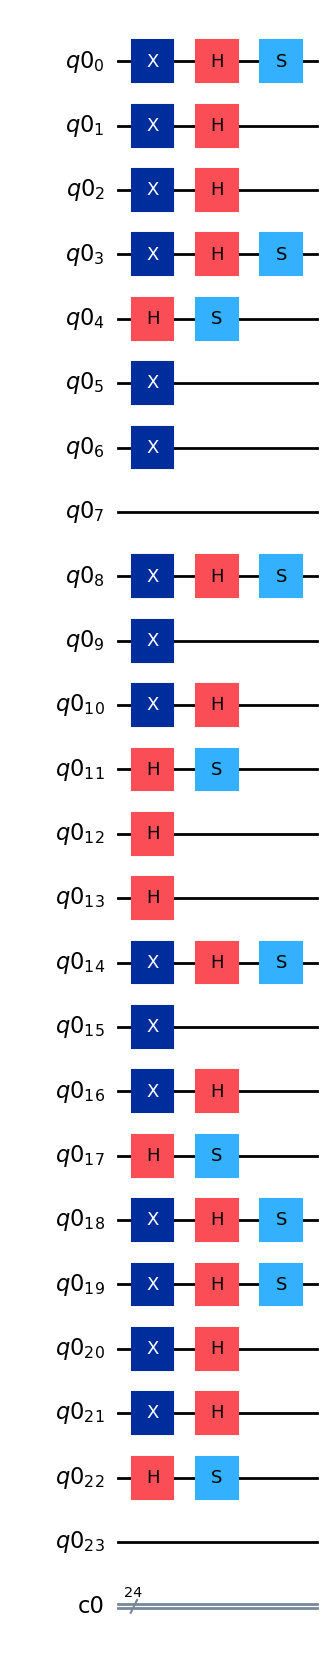

In [2]:
#Apply X gate if bit is equal to 1
for i, n in enumerate(send):
    if n==1:
        asja.x(qreg[i]) # apply x-gate
for i, k in enumerate(asja_basis): 
    if k=='X':
        asja.h(qreg[i])
    if k=="Y":
        asja.h(qreg[i])
        asja.s([qreg[i]])
            
        send_str = ''.join(str(e) for e in send)



asja.draw("mpl") #To check gates applied correctly/'

**In this cell Balvis will recieve the states with some blit flip errors and then will apply gates according to his basis.**

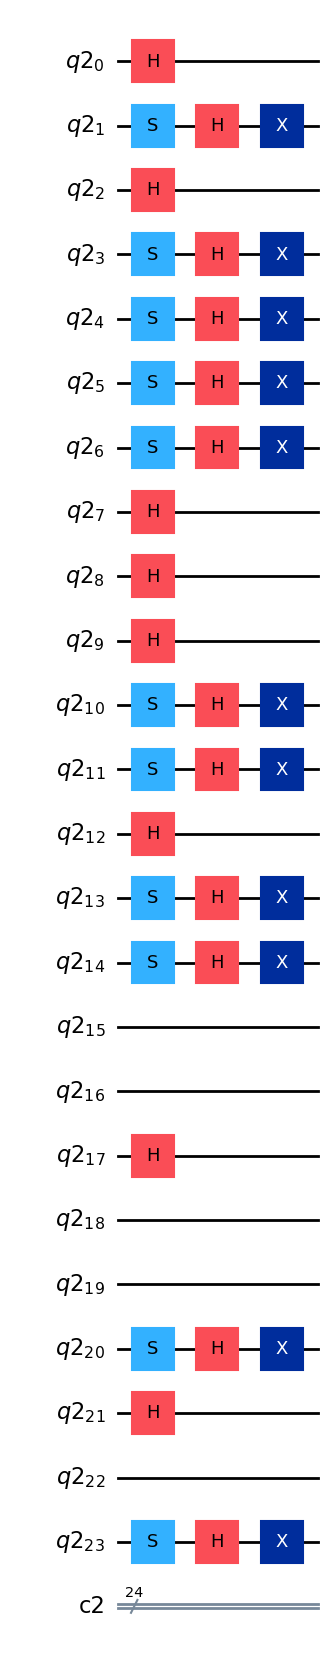

In [8]:
balvis = QuantumCircuit(qreg, creg, name='Balvis') #Defining Balvis circuit
NoisyChannel(asja, balvis, 'Asja') #Asja sends states to Balvis

for i, k in enumerate(balvis_basis): 
    if k=='X':
        balvis.h(qreg[i])
    if k=="Y":
        balvis.s(qreg[i])
        balvis.h(qreg[i])
        balvis.x(qreg[i])


            

balvis.draw("mpl")

**Balvis will measure the states in computational basis.**

In [9]:
from qiskit_aer import AerSimulator
from qiskit.compiler import transpile

# measurement (same)
balvis.measure(qreg, creg)

# create simulator backend
sim = AerSimulator()

# transpile circuit for simulator
compiled_circuit = transpile(balvis, sim)

# run simulation
job = sim.run(compiled_circuit, shots=1)
result = job.result()

# get counts
counts = result.get_counts()

received = print_outcomes_in_reverse(counts)

print("Asja sent:", send_str)
print("Balvis received:", received)

Asja sent: 111101101110001110111100
Balvis received: 010000101000111001000000


**The sifted key Balvis and Asja would keep.**

In [10]:

asja_key=[] #Asjas register for matching rounds
balvis_key=[] #Balvis register for matching rounds
for j in range(0,len(asja_basis)): #Going through list of bases 
    if asja_basis[j] == balvis_basis[j]: #Comparing
        asja_key.append(send[j])
        balvis_key.append(received[j]) #Keeping key bit if bases matched
    else:
        pass #Discard round if bases mismatched
balvis_key = [eval(i) for i in balvis_key]

print("Asjas key =", asja_key)
print("Balvis key =", balvis_key)
        

Asjas key = [1, 1, 0, 0, 0, 1, 1, 1, 1]
Balvis key = [0, 0, 0, 0, 0, 1, 0, 0, 0]


**Error Correction**

In [11]:
rounds = len(asja_key)//3    #To divide without remainer, use //

errors=0
for i in range(rounds):
    bit_index = randrange(len(asja_key)) 
    
    tested_bit = asja_key[bit_index]
    print ("Asja randomly selected bit index =", bit_index, ", and its value is = ", tested_bit)
    if asja_key[bit_index]!=balvis_key[bit_index]: #comparing tested rounds
        errors=errors+1 #calculating errors
    #removing tested bits from key strings
    del asja_key[bit_index] #Use del to specify the index of the element you want to delete
    del balvis_key[bit_index]
if rounds!=0:
    QBER=errors/rounds #calculating QBER
else:
    print("the key is too short for privacy amplification ")       
print("QBER value =", QBER)
print("Asjas secret key =", asja_key)
print("Balvis secret key =", balvis_key)
print("Number of errors = ", errors)


Asja randomly selected bit index = 7 , and its value is =  1
Asja randomly selected bit index = 4 , and its value is =  0
Asja randomly selected bit index = 1 , and its value is =  1
QBER value = 0.6666666666666666
Asjas secret key = [1, 0, 0, 1, 1, 1]
Balvis secret key = [0, 0, 0, 1, 0, 0]
Number of errors =  2


### Error Correction and Privacy Amplification
The key can be made error free and private by the classical error correction and privacy amplification methods as in BB84.

## Task
As you saw in this protocol the error was introduced during the process of sending (In the function StateSend) can you introduce the error by actually introducing an evesdropper? 
### Hint
When Asja send the state to Balvis, on the way Eve measures the states and then sends it to Balvis. You can implement this protocol by giving Eve the initial quantum circuit of Asja and giving Balvis the initial circuit of Eve.

Check the answer here:


[Answer](six_states_with_evesdropper.ipynb)